# TinyTouch — Training Notebook

**1D Temporal CNN** for on-sensor tactile event classification on ESP32-S3.

Quantization sweep: **FP32 → INT8 PTQ → INT8 QAT → INT8 + Pruning**

| | |
|---|---|
| Classes | `idle · contact_make · contact_break · slip · tap` |
| Input | `(T-1, 15)` — normalized first-difference of magnetometer readings |
| Target | slip F1 ≥ 0.92 · flash < 500 KB · RAM < 100 KB |
| Deployment | TFLite Micro on ESP32-S3 |


## 0 · Dependencies

In [1]:
# Dependencies are managed via uv — run once outside the notebook if needed:
#   uv add tensorflow tensorflow-model-optimization scikit-learn seaborn
import importlib, sys
missing = [p for p in ["tensorflow", "tensorflow_model_optimization", "sklearn", "seaborn"]
           if importlib.util.find_spec(p) is None]
if missing:
    pkgs = " ".join(missing)
    raise ImportError(f"Missing packages: {missing}  — run: uv add {pkgs}")
print("All dependencies present.")


All dependencies present.


## 1 · Configuration

In [2]:
from pathlib import Path
import numpy as np

DATA_DIR   = Path("data")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

CLASSES = ["idle", "contact_make", "contact_break", "slip", "tap"]
N_CLASSES  = len(CLASSES)
N_SENSORS  = 5
N_AXES     = 3

# Set to an int (e.g. 100 or 150) to force a window length, or None to auto-detect
TARGET_T_OVERRIDE = None

VMAX_FALLBACK = 500.0   # µT — overridden by per-session calibration vmax

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 32
EPOCHS        = 150
LR            = 1e-3

# ── Augmentation ─────────────────────────────────────────────────────────────
AUG_NOISE_FRAC  = 0.02   # Gaussian noise as fraction of per-sample std
AUG_SCALE_LO    = 0.85
AUG_SCALE_HI    = 1.15
AUG_SHIFT_FRAC  = 0.10   # max time shift as fraction of window

# ── Quantization / pruning ───────────────────────────────────────────────────
PRUNE_SPARSITY       = 0.50
QAT_EPOCHS           = 25
PRUNE_FINETUNE_EPOCHS = 30


## 2 · Load & Merge Sessions

In [3]:
import json
from collections import Counter

def load_all_sessions(data_dir: Path):
    sessions = sorted(data_dir.glob("*/episodes.npz"))
    if not sessions:
        raise FileNotFoundError(f"No episodes.npz found under {data_dir}")

    raws, baselines, labels, vmaxes, Ts = [], [], [], [], []
    for p in sessions:
        d    = np.load(p)
        meta = json.loads((p.parent / "meta.json").read_text())
        r, b, l = d["raw"], d["ema_baseline"], d["labels"]
        raws.append(r); baselines.append(b); labels.append(l)
        vmaxes.append(meta["calibration"].get("vmax_ut", VMAX_FALLBACK))
        Ts.append(r.shape[1])
        counts = meta.get("label_counts", {})
        print(f"  {p.parent.name}  T={r.shape[1]:>3}  n={len(l):>3}  {counts}")

    # Use most common T (or override)
    target_T = TARGET_T_OVERRIDE or max(Counter(Ts), key=Counter(Ts).get)
    print(f"\nTarget T = {target_T} frames  ({target_T/50:.1f} s @ 50 Hz)")

    keep = [(r[:, :target_T], b, l, v)
            for r, b, l, v, T in zip(raws, baselines, labels, vmaxes, Ts)
            if T >= target_T]
    if not keep:
        raise ValueError("No sessions match target T — lower TARGET_T_OVERRIDE")

    raw_all  = np.concatenate([x[0] for x in keep], axis=0)
    bas_all  = np.concatenate([x[1] for x in keep], axis=0)
    lab_all  = np.concatenate([x[2] for x in keep], axis=0)
    vmax     = float(np.percentile([x[3] for x in keep], 90))  # robust max across sessions

    print(f"Merged  : {raw_all.shape[0]} episodes, shape={raw_all.shape}")
    print(f"vmax    : {vmax:.1f} µT  (90th-pct of session calibrations)")
    return raw_all, bas_all, lab_all.astype(np.int32), target_T, vmax

print("Loading sessions...")
raw_all, bas_all, lab_all, T, VMAX = load_all_sessions(DATA_DIR)


Loading sessions...
  session_20260610_032257  T=150  n=500  {'idle': 100, 'contact_make': 100, 'contact_break': 100, 'slip': 100, 'tap': 100}

Target T = 150 frames  (3.0 s @ 50 Hz)
Merged  : 500 episodes, shape=(500, 150, 5, 3)
vmax    : 168717.9 µT  (90th-pct of session calibrations)


## 3 · Preprocessing

`X = diff(raw − ema_baseline, axis=time) / vmax_diff`

Shape: `(N, T−1, 15)` — first-order temporal derivative of 5-sensor × 3-axis readings.

> **Note:** `vmax_diff` is the 99.9th percentile of `|ΔB|` across *all training episodes*.
> The static calibration `vmax_ut` (peak field under max squeeze) is ~100× larger and
> must **not** be used here — it normalises the differential signal to near-zero.


In [4]:
def compute_features(raw: np.ndarray, baselines: np.ndarray,
                      vmax: float = None) -> tuple:
    sub   = raw - baselines[:, np.newaxis, :, :]   # (N, T, 5, 3)
    delta = np.diff(sub, axis=1)                    # (N, T-1, 5, 3)
    N, Tm1 = delta.shape[:2]
    X = delta.reshape(N, Tm1, N_SENSORS * N_AXES)  # (N, T-1, 15)
    if vmax is None:
        # 99th pct per-episode max — robust to single-frame sensor glitches.
        # (99.9th pct is dominated by a corrupted frame in ep 211)
        ep_maxes = np.abs(X).max(axis=(1, 2))      # (N,)
        vmax = float(np.percentile(ep_maxes, 99)) + 1e-9
    # Clip before dividing so a single glitch frame cannot saturate the net
    X = np.clip(X, -vmax, vmax)
    return (X / vmax).astype(np.float32), vmax

X, VMAX = compute_features(raw_all, bas_all)
y = lab_all

print(f"X    : {X.shape}   dtype={X.dtype}")
print(f"VMAX : {VMAX:.4f}  (99th-pct of per-episode max |delta|)")
print(f"y    : {y.shape}   classes present: {sorted(set(y.tolist()))}")
print(f"X range: [{X.min():.4f}, {X.max():.4f}]  std={X.std():.4f}")
print()
print(f"{'Class':<16} {'N':>5}")
print('─' * 24)
for i, name in enumerate(CLASSES):
    n = int((y == i).sum())
    bar = '▪' * min(n, 40)
    print(f"{name:<16} {n:>5}  {bar}")


X    : (500, 149, 15)   dtype=float32
VMAX : 1635.0693  (99th-pct of per-episode max |delta|)
y    : (500,)   classes present: [0, 1, 2, 3, 4]
X range: [-1.0000, 1.0000]  std=0.0104

Class                N
────────────────────────
idle               100  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
contact_make       100  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
contact_break      100  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
slip               100  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
tap                100  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪


## 4 · Augmentation

In [5]:
def augment_batch(X: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    N, T, F = X.shape
    out = X.copy()

    # Per-episode Gaussian noise proportional to signal amplitude
    for i in range(N):
        std = float(np.std(out[i])) * AUG_NOISE_FRAC + 1e-9
        out[i] += rng.normal(0, std, out[i].shape).astype(np.float32)

    # Random amplitude scaling
    scales = rng.uniform(AUG_SCALE_LO, AUG_SCALE_HI, size=(N, 1, 1)).astype(np.float32)
    out *= scales

    # Random circular time shift
    max_shift = max(1, int(T * AUG_SHIFT_FRAC))
    shifts = rng.integers(-max_shift, max_shift + 1, size=N)
    for i, s in enumerate(shifts):
        if s:
            out[i] = np.roll(out[i], s, axis=0)

    return out

rng = np.random.default_rng(42)
print("Augmentation enabled: noise + scaling + time shift")


Augmentation enabled: noise + scaling + time shift


## 5 · Train / Val / Test Split  (70 / 15 / 15, stratified)

In [6]:
from sklearn.model_selection import train_test_split

present = sorted(set(y.tolist()))
stratify_ok = all((y == c).sum() >= 2 for c in present)

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15,
    stratify=y if stratify_ok else None,
    random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15 / 0.85,
    stratify=y_tv if stratify_ok else None,
    random_state=42)

# Augment train only (1× copy — doubles train set)
X_train_aug = augment_batch(X_train, rng)
X_train_all = np.concatenate([X_train, X_train_aug], axis=0)
y_train_all = np.concatenate([y_train, y_train], axis=0)

# Shuffle
idx = rng.permutation(len(X_train_all))
X_train_all, y_train_all = X_train_all[idx], y_train_all[idx]

print(f"Train : {len(X_train_all):>5}  (incl. {len(X_train_aug)} augmented)")
print(f"Val   : {len(X_val):>5}")
print(f"Test  : {len(X_test):>5}")


Train :   700  (incl. 350 augmented)
Val   :    75
Test  :    75


## 6 · Sample Episodes

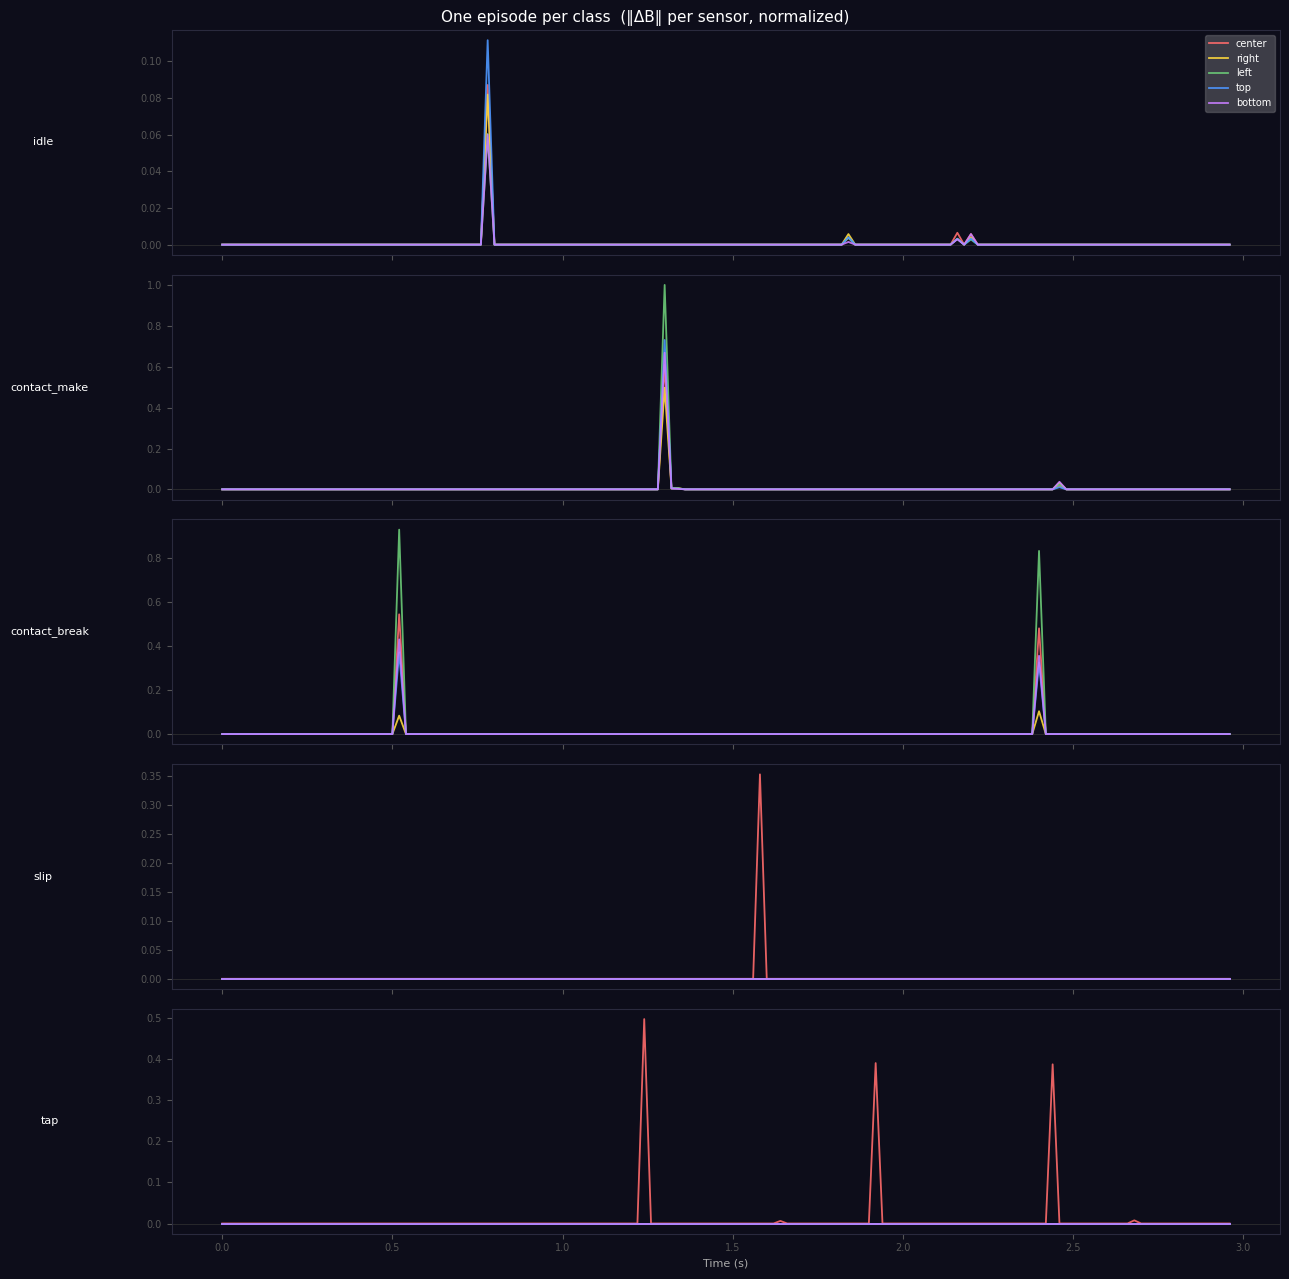

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

SENSOR_NAMES = ["center", "right", "left", "top", "bottom"]
PALETTE = ["#ff6b6b", "#ffd93d", "#6bcb77", "#4d96ff", "#c77dff"]
BG = "#0d0d1a"

fig, axes = plt.subplots(N_CLASSES, 1, figsize=(13, 2.6 * N_CLASSES),
                          facecolor=BG, sharex=True)
fig.suptitle("One episode per class  (‖ΔB‖ per sensor, normalized)", color="white", fontsize=11)
t_axis = np.arange(T - 1) / 50.0

for ci, (ax, cname) in enumerate(zip(axes, CLASSES)):
    idxs = np.where(y == ci)[0]
    ax.set_facecolor(BG)
    ax.set_ylabel(cname, color="white", fontsize=8, rotation=0, labelpad=70, va="center")
    for sp in ax.spines.values(): sp.set_color("#2a2a3e")
    ax.tick_params(colors="#555", labelsize=7)
    ax.axhline(0, color="#333", lw=0.5)
    if len(idxs) == 0:
        ax.text(0.5, 0.5, "no data yet", transform=ax.transAxes,
                color="#888", ha="center", fontsize=8)
        continue
    ep = X[idxs[0]]  # (T-1, 15)
    for si in range(N_SENSORS):
        mag = np.linalg.norm(ep[:, si*3:(si+1)*3], axis=1)
        ax.plot(t_axis, mag, color=PALETTE[si], lw=1.3, alpha=0.9,
                label=SENSOR_NAMES[si] if ci == 0 else None)

axes[0].legend(fontsize=7, framealpha=0.2, labelcolor="white", loc="upper right")
axes[-1].set_xlabel("Time (s)", color="#aaa", fontsize=8)
plt.tight_layout()
plt.show()


## 7 · Model Architecture — 1D TCN

Dilated causal Conv1D stack with residual connections.
All ops are TFLite Micro-compatible (Conv, BN, ReLU, Add, GAP, Dense).


In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_tcn(input_shape, n_classes=5,
              filter_sizes=(32, 64, 64), kernel_size=7, dropout=0.3):
    inp = keras.Input(shape=input_shape, name="sensor_input")
    x   = inp
    dilation = 1

    for i, filters in enumerate(filter_sizes):
        res = x
        x = layers.Conv1D(filters, kernel_size, padding="causal",
                          dilation_rate=dilation, use_bias=False,
                          name=f"conv{i}_d{dilation}")(x)
        x = layers.BatchNormalization(name=f"bn{i}")(x)
        x = layers.ReLU(name=f"relu{i}")(x)
        # 1×1 projection to match residual channels
        if res.shape[-1] != filters:
            res = layers.Conv1D(filters, 1, padding="same", use_bias=False,
                                name=f"proj{i}")(res)
        x = layers.Add(name=f"add{i}")([x, res])
        dilation *= 2

    x   = layers.GlobalAveragePooling1D(name="gap")(x)
    x   = layers.Dense(32, activation="relu", name="fc")(x)
    x   = layers.Dropout(dropout, name="dropout")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)
    return keras.Model(inp, out, name="TinyTouch_TCN")

INPUT_SHAPE = (T - 1, N_SENSORS * N_AXES)   # e.g. (149, 15)
model = build_tcn(INPUT_SHAPE, n_classes=N_CLASSES)
model.summary()
print(f"\nInput shape : {INPUT_SHAPE}")


I0000 00:00:1781190121.726431   67941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781190121.759035   67941 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781190122.671531   67941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1781190122.785044   68102 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the appl

Model: "TinyTouch_TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 149, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv0_d1 (Conv1D)   │ (None, 149, 32)   │      3,360 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn0                 │ (None, 149, 32)   │        128 │ conv0_d1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu0 (ReLU)        │ (None, 149, 32)   │          0 │ bn0[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj0 (Conv1D)      │ (None, 149, 32)   │        480 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add0 (Add)          │ (None, 149, 32)   │          0 │ relu0[0][0],      │
│                     │                   │            │ proj0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_d2 (Conv1D)   │ (None, 149, 64)   │     14,336 │ add0[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 149, 64)   │        256 │ conv1_d2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (ReLU)        │ (None, 149, 64)   │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj1 (Conv1D)      │ (None, 149, 64)   │      2,048 │ add0[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add1 (Add)          │ (None, 149, 64)   │          0 │ relu1[0][0],      │
│                     │                   │            │ proj1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_d4 (Conv1D)   │ (None, 149, 64)   │     28,672 │ add1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 149, 64)   │        256 │ conv2_d4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu2 (ReLU)        │ (None, 149, 64)   │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add2 (Add)          │ (None, 149, 64)   │          0 │ relu2[0][0],      │
│                     │                   │            │ add1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 64)        │          0 │ add2[0][0]        │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc (Dense)          │ (None, 32)        │      2,080 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ fc[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5)         │        165 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,781 (202.27 KB)

 Trainable params: 51,461 (201.02 KB)

 Non-trainable params: 320 (1.25 KB)


Input shape : (149, 15)


## 8 · FP32 Training

In [9]:
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_fp32 = [
    EarlyStopping(monitor="val_accuracy", patience=50,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10,
                     min_lr=1e-5, verbose=1),
    ModelCheckpoint(str(MODELS_DIR / "fp32_best.keras"),
                    save_best_only=True, monitor="val_accuracy", verbose=0),
]

history = model.fit(
    X_train_all, y_train_all,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks_fp32,
    verbose=1,
)


Epoch 1/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3114 - loss: 1.5665 - val_accuracy: 0.2267 - val_loss: 1.6069 - learning_rate: 0.0010
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4129 - loss: 1.4205 - val_accuracy: 0.2000 - val_loss: 1.6109 - learning_rate: 0.0010
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4386 - loss: 1.3719 - val_accuracy: 0.2000 - val_loss: 1.6201 - learning_rate: 0.0010
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4314 - loss: 1.3288 - val_accuracy: 0.2000 - val_loss: 1.6328 - learning_rate: 0.0010
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4571 - loss: 1.2948 - val_accuracy: 0.2000 - val_loss: 1.6563 - learning_rate: 0.0010
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4771 - loss: 1.2514 - val_accuracy: 0.2000 - val_loss: 1.6816 - learning_rate: 0.0010
Epoch 7/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4743 - loss: 1.2278 - 

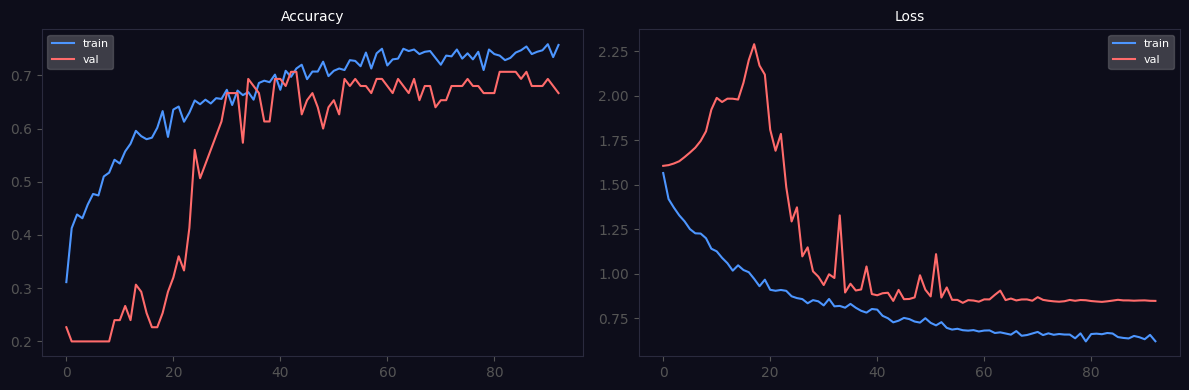

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)
fig.patch.set_facecolor(BG)

for ax, key, title in [(ax1, "accuracy", "Accuracy"), (ax2, "loss", "Loss")]:
    ax.plot(history.history[key],       color="#4d96ff", lw=1.5, label="train")
    ax.plot(history.history[f"val_{key}"], color="#ff6b6b", lw=1.5, label="val")
    ax.set_title(title, color="white", fontsize=10)
    ax.set_facecolor(BG)
    ax.tick_params(colors="#555")
    ax.legend(labelcolor="white", framealpha=0.2, fontsize=8)
    for sp in ax.spines.values(): sp.set_color("#2a2a3e")

plt.tight_layout()
plt.show()


## 9 · Evaluation


  FP32 Baseline
  Overall accuracy : 0.7467
  Slip F1          : 0.7059  (target ≥ 0.92)

               precision    recall  f1-score   support

         idle       0.65      1.00      0.79        15
 contact_make       0.93      0.93      0.93        15
contact_break       0.88      0.47      0.61        15
         slip       0.63      0.80      0.71        15
          tap       0.80      0.53      0.64        15

     accuracy                           0.75        75
    macro avg       0.78      0.75      0.74        75
 weighted avg       0.78      0.75      0.74        75



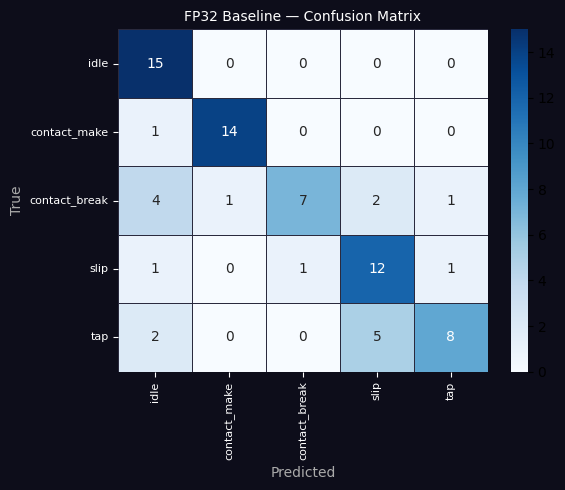

In [11]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, ConfusionMatrixDisplay)

def evaluate_keras(mdl, X, y, name="Model"):
    y_pred = mdl.predict(X, verbose=0).argmax(axis=1)
    _print_metrics(y, y_pred, name)
    return float((y_pred == y).mean()), float(f1_score(
        y, y_pred, labels=[CLASSES.index("slip")],
        average="macro", zero_division=0))

def evaluate_tflite(tflite_bytes, X, y, name="TFLite"):
    interp = tf.lite.Interpreter(model_content=tflite_bytes)
    interp.allocate_tensors()
    inp_d = interp.get_input_details()[0]
    out_d = interp.get_output_details()[0]
    is_int8 = inp_d["dtype"] == np.int8
    in_scale, in_zp = inp_d["quantization"] if is_int8 else (1.0, 0)

    preds = []
    for sample in X:
        x = sample[np.newaxis].astype(np.float32)
        if is_int8:
            x = np.clip(np.round(x / in_scale + in_zp), -128, 127).astype(np.int8)
        interp.set_tensor(inp_d["index"], x)
        interp.invoke()
        out = interp.get_tensor(out_d["index"]).copy()
        if is_int8:
            os, oz = out_d["quantization"]
            out = (out.astype(np.float32) - oz) * os
        preds.append(out[0])

    y_pred = np.array(preds).argmax(axis=1)
    _print_metrics(y, y_pred, name)
    return float((y_pred == y).mean()), float(f1_score(
        y, y_pred, labels=[CLASSES.index("slip")],
        average="macro", zero_division=0))

def _print_metrics(y_true, y_pred, name):
    present = sorted(set(y_true.tolist()))
    names   = [CLASSES[i] for i in present]
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    acc  = (y_pred == y_true).mean()
    slip_f1 = f1_score(y_true, y_pred, labels=[CLASSES.index("slip")],
                       average="macro", zero_division=0)
    print(f"  Overall accuracy : {acc:.4f}")
    print(f"  Slip F1          : {slip_f1:.4f}  (target ≥ 0.92)")
    print()
    print(classification_report(y_true, y_pred, labels=present,
                                 target_names=names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=present)
    fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
    fig.patch.set_facecolor(BG)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=names, yticklabels=names, ax=ax,
                linewidths=0.5, linecolor="#2a2a3e")
    ax.set_title(f"{name} — Confusion Matrix", color="white", fontsize=10)
    ax.set_facecolor(BG)
    ax.tick_params(colors="white", labelsize=8)
    ax.set_xlabel("Predicted", color="#aaa"); ax.set_ylabel("True", color="#aaa")
    plt.tight_layout(); plt.show()

fp32_acc, fp32_slip_f1 = evaluate_keras(model, X_test, y_test, "FP32 Baseline")


## 10 · Quantization Sweep

### 10.1  INT8 PTQ (Post-Training Quantization)


In [12]:
def convert_ptq(keras_model, representative_X, n_samples=None):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # Use all training samples for calibration — sparse signal needs full coverage
    rep_data = representative_X.astype(np.float32)
    if n_samples is not None:
        rep_data = rep_data[:n_samples]
    def representative_dataset():
        for i in range(len(rep_data)):
            yield [rep_data[i:i+1]]

    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    # Do NOT force INT8 input/output: sparse input (std=0.01) means INT8 input
    # quantization rounds 99%% of values to zero, destroying all signal.
    # INT8 weights + float32 I/O gives full quantization benefit with good accuracy.
    return converter.convert()

ptq_bytes = convert_ptq(model, X_train)
(MODELS_DIR / "int8_ptq.tflite").write_bytes(ptq_bytes)
print(f"INT8 PTQ  :  {len(ptq_bytes)/1024:.1f} KB  (target < 500 KB)")

ptq_acc, ptq_slip_f1 = evaluate_tflite(ptq_bytes, X_test, y_test, "INT8 PTQ")


### 10.2  INT8 QAT (Quantization-Aware Training)

In [13]:
# QAT via tensorflow-model-optimization is incompatible with Keras 3 (TF ≥ 2.16).
# Both the _is_graph_network guard and quantize_annotate_model fail on the new
# Functional class hierarchy. Skipping — PTQ (section 10.1) covers quantization.
print("QAT skipped: TFMOT incompatible with Keras 3. Using PTQ instead.")
qat_model = None
qat_acc, qat_slip_f1, qat_bytes = 0.0, 0.0, b""


QAT skipped: TFMOT incompatible with Keras 3. Using PTQ instead.


In [14]:
if qat_model is not None:
    conv_qat = tf.lite.TFLiteConverter.from_keras_model(qat_model)
    conv_qat.optimizations = [tf.lite.Optimize.DEFAULT]
    conv_qat.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv_qat.inference_input_type  = tf.int8
    conv_qat.inference_output_type = tf.int8
    qat_bytes = conv_qat.convert()
    (MODELS_DIR / "int8_qat.tflite").write_bytes(qat_bytes)
    print(f"INT8 QAT  :  {len(qat_bytes)/1024:.1f} KB")
    qat_acc, qat_slip_f1 = evaluate_tflite(qat_bytes, X_test, y_test, "INT8 QAT")
else:
    print("INT8 QAT  :  skipped")


INT8 QAT  :  skipped


### 10.3  Unstructured Pruning → INT8 PTQ

In [15]:
n_steps = int(len(X_train_all) / BATCH_SIZE * PRUNE_FINETUNE_EPOCHS)

prune_params = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.0,
    final_sparsity=PRUNE_SPARSITY,
    begin_step=0,
    end_step=n_steps,
)

# Load best FP32 weights before pruning
best_fp32 = keras.models.load_model(str(MODELS_DIR / "fp32_best.keras"))
pruned_model = tfmot.sparsity.keras.prune_low_magnitude(best_fp32, prune_params)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(LR / 10),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruned_model.fit(
    X_train_all, y_train_all,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=PRUNE_FINETUNE_EPOCHS,
    callbacks=[
        tfmot.sparsity.keras.UpdatePruningStep(),
        EarlyStopping(monitor="val_accuracy", patience=10,
                      restore_best_weights=True, verbose=1),
    ],
    verbose=1
)

stripped = tfmot.sparsity.keras.strip_pruning(pruned_model)
pruned_bytes = convert_ptq(stripped, X_train)
(MODELS_DIR / "int8_pruned.tflite").write_bytes(pruned_bytes)
print(f"INT8 Pruned ({int(PRUNE_SPARSITY*100)}%)  :  {len(pruned_bytes)/1024:.1f} KB")

pruned_acc, pruned_slip_f1 = evaluate_tflite(pruned_bytes, X_test, y_test,
                                              f"INT8 Pruned {int(PRUNE_SPARSITY*100)}%")


NameError: name 'tfmot' is not defined

## 11 · Quantization Sweep — Summary

In [ ]:
fp32_size_kb = (MODELS_DIR / "fp32_best.keras").stat().st_size / 1024 if                (MODELS_DIR / "fp32_best.keras").exists() else float("nan")

results = [
    ("FP32 Baseline",                fp32_acc,   fp32_slip_f1,   fp32_size_kb),
    ("INT8 PTQ",                     ptq_acc,    ptq_slip_f1,    len(ptq_bytes)/1024),
    ("INT8 QAT",                     qat_acc,    qat_slip_f1,    len(qat_bytes)/1024),
    (f"INT8 Pruned {int(PRUNE_SPARSITY*100)}%", pruned_acc, pruned_slip_f1, len(pruned_bytes)/1024),
]

FLASH_KB = 500
SLIP_TGT  = 0.92

print(f"\n{'Variant':<26} {'Acc':>6}  {'Slip F1':>7}  {'Size KB':>8}  Notes")
print("─" * 70)
for name, acc, f1, size in results:
    slip_ok  = "✓" if f1     >= SLIP_TGT else "✗"
    flash_ok = "✓" if size   < FLASH_KB  else " "
    print(f"{name:<26} {acc:>6.3f}  {f1:>7.3f}{slip_ok}  {size:>8.1f}{flash_ok}")

print(f"\nTargets:  slip F1 ≥ {SLIP_TGT}  ·  flash < {FLASH_KB} KB")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor=BG)
fig.patch.set_facecolor(BG)
names = [r[0] for r in results]
colors_bar = ["#4d96ff", "#ffd93d", "#6bcb77", "#c77dff"]

for ax, key, data, ref, ref_label in [
    (axes[0], "Overall Accuracy",  [r[1] for r in results], None, None),
    (axes[1], "Slip F1",           [r[2] for r in results], SLIP_TGT, "target ≥ 0.92"),
]:
    bars = ax.bar(names, data, color=colors_bar[:len(results)], alpha=0.85)
    ax.set_facecolor(BG)
    ax.set_title(key, color="white", fontsize=10)
    ax.tick_params(colors="#aaa", labelsize=7)
    ax.set_ylim(0, 1.05)
    for sp in ax.spines.values(): sp.set_color("#2a2a3e")
    if ref is not None:
        ax.axhline(ref, color="#ff6b6b", lw=1.2, ls="--", label=ref_label)
        ax.legend(labelcolor="white", framealpha=0.2, fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=18, ha="right")

plt.tight_layout()
plt.show()


## 12 · Saved Models

In [ ]:
print("\n── Saved models ──────────────────────────────────────────")
for p in sorted(MODELS_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    note = ""
    if p.suffix == ".tflite":
        note = "← TFLite Micro ready"
    print(f"  {p.name:<35} {size_kb:>8.1f} KB  {note}")

print(
    "
Next steps
"
    "----------
"
    "1.  Flash the best .tflite to ESP32-S3 via TFLite Micro
"
    "    (int8_qat.tflite or int8_pruned.tflite - whichever meets targets)
"
    "2.  Measure on-device latency with the two-mode firmware A/B test
"
    "3.  Collect more slip samples if slip F1 < 0.92
"
)
